In [ ]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import math
import time
from datetime import datetime, timezone, timedelta

from pathlib import Path
from typing import Optional

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

In [12]:
market_context = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Inflation': [0.1291, 0.0538, 0.0252, 0.0427, 0.0305, 0.0491, 0.0839, 0.1192, 0.0742, 0.0951, 0.0599],
    'BankRate':  [0.15325, 0.0999, 0.084, 0.07245, 0.07529, 0.05927, 0.04486, 0.07738, 0.0813, 0.14793, 0.21723]
}
df_market = pd.DataFrame(market_context).set_index('Year')

In [13]:
def clean_market_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Очищает данные от пропусков и нулевых значений.
    """
    df = df.copy()
    
    # 1. Заменяем чистые нули на NaN (в цене Close/Open нулей быть не может)
    # Делаем это только для колонок с ценами
    cols_to_fix = ['Open', 'High', 'Low', 'Close']
    for col in cols_to_fix:
        df[col] = df[col].replace(0, pd.NA)
    
    # 2. Сортируем по времени (важно для правильного заполнения "вперед")
    df = df.sort_values("DateTime")
    
    # 3. Forward Fill: заполняем пропуски последним известным значением
    df[cols_to_fix] = df[cols_to_fix].ffill()
    
    # 4. Backward Fill: на случай, если пропуски в самых первых строках
    df[cols_to_fix] = df[cols_to_fix].bfill()
    
    # 5. Обработка объема (Volume)
    # Для объема пропуски лучше заменять на 0, так как сделок просто не было
    df['Volume'] = df['Volume'].fillna(0)
    
    return df

In [14]:
def prepare_daily_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Превращает любые данные (минуты, часы) в чистые дневные бары для стратегий.
    """
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df['DateTime'] = pd.to_datetime(df['DateTime'])
        df = df.set_index('DateTime')
    
    # Агрегируем: Open - первый в дне, Close - последний, Volume - сумма
    df_daily = df.resample('D').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    })
    
    # Заполняем выходные и праздники (биржи закрыты, цена не менялась)
    df_daily[['Open', 'High', 'Low', 'Close']] = df_daily[['Open', 'High', 'Low', 'Close']].ffill()
    df_daily['Volume'] = df_daily['Volume'].fillna(0)
    
    return df_daily.sort_index()

In [15]:
def fill_time_gaps(df: pd.DataFrame, interval_name: str = "5min") -> pd.DataFrame:
    """
    Вставляет пропущенные временные интервалы (строки), которых нет в данных.
    """
    # Маппинг для метода resample
    resample_map = {
        "5min": "5min", "15min": "15min", "1hour": "h", "1day": "D"
    }
    freq = resample_map.get(interval_name, "5min")
    
    df = df.set_index("DateTime").sort_index()
    
    # Создаем полный индекс без дыр от начала до конца
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
    
    # Переиндексируем (появятся строки с NaN там, где были дыры)
    df = df.reindex(full_range)
    df.index.name = "DateTime"
    
    # Заполняем пустоты
    df[['Open', 'High', 'Low', 'Close']] = df[['Open', 'High', 'Low', 'Close']].ffill()
    df['Volume'] = df['Volume'].fillna(0)
    
    return df.reset_index()

Стратегия DCA (Dollar Cost Averaging)
Вы покупаете 10-го и 25-го числа. Если день выходной, мы берем ближайший предыдущий рабочий день

In [16]:
def benchmark_dca(df: pd.DataFrame, investment_per_step: float = 1000, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    # 1. Подготовка индекса
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
    
    df.index = df.index.normalize()
    df = df.sort_index()

    # 2. Фильтрация и агрегация до дней (на случай интрадея)
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    total_shares = 0
    total_invested = 0
    current_cash = 0 
    daily_history = []

    # 3. Основной цикл стратегии
    for date, row in df.iterrows():
        if date.day in [10, 25]:
            buy_price = row['Open']
            if buy_price > 0:
                available_money = investment_per_step + current_cash
                total_invested += investment_per_step
                
                max_shares = available_money / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares_to_buy = num_lots * lot_size
                
                purchase_cost = shares_to_buy * buy_price
                total_fee = purchase_cost * fee
                
                total_shares += shares_to_buy
                current_cash = available_money - (purchase_cost + total_fee)
        
        portfolio_value = (total_shares * row['Close']) + current_cash
        
        daily_history.append({
            'DateTime': date,
            'Balance': portfolio_value,
            'Invested': total_invested
        })

    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    if temp_df.empty: return 0.0, 0.0, pd.DataFrame()

    # 4. Агрегация в годовую таблицу
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        if len(annual_history) == 0:
            # Первый год: база для профита — это первые внесенные деньги
            first_invested = year_data[year_data['Invested'] > 0]['Invested'].iloc[0] if any(year_data['Invested'] > 0) else 0
            profit = last_balance - invested_at_end
            prev_balance = first_invested
        else:
            prev_balance = annual_history[-1]['Balance']
            # Пополнения за текущий год
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            # Прибыль = Конец года - (Начало года + Довнесения)
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / (prev_balance + (invested_at_end - (annual_history[-1]['Invested'] if len(annual_history) > 0 else 0)) / 2)
        # Упрощенный Rate для наглядности (как в банковской таблице)
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Итоговые метрики
    final_balance = history_df['Balance'].iloc[-1]
    final_profit_pct = ((final_balance - total_invested) / total_invested * 100) if total_invested > 0 else 0
    
    return final_profit_pct, final_balance, history_df

Стратегия "Sell in May and Go Away"
Классическая поговорка гласит: «Продавай в мае и уходи, возвращайся в День всех святых (ноябрь)». Логика: Мы владеем активом только с 1 ноября по 30 апреля. В остальное время мы «в кэше» (деньги просто лежат)

In [17]:
def benchmark_sell_in_may(df: pd.DataFrame, initial_capital: float = 100000, n: float = 0, fee: float = 0, lot_size: int = 1, start_year: int = None, end_year: int = None) -> tuple[float, float, pd.DataFrame]:
    df = df.copy()
    
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'DateTime' in df.columns:
            df['DateTime'] = pd.to_datetime(df['DateTime']).dt.tz_localize(None)
            df = df.set_index('DateTime')
        else:
            df.index = pd.to_datetime(df.index).tz_localize(None)
            
    if start_year: df = df[df.index.year >= start_year]
    if end_year: df = df[df.index.year <= end_year]
    
    # Гарантируем дневной формат, чтобы не множить комиссии на интрадее
    df = df.resample('D').agg({'Open': 'first', 'Close': 'last'}).ffill()
    
    in_market_months = [11, 12, 1, 2, 3, 4]
    current_cash = initial_capital
    total_invested = initial_capital 
    shares = 0
    in_position = False
    daily_history = []
    n_added_this_year = False

    for date, row in df.iterrows():
        month = date.month
        if month == 11: n_added_this_year = False
        
        # Логика входа (Ноябрь)
        if month in in_market_months and not in_position:
            buy_price = row['Open']
            if buy_price > 0:
                max_shares = current_cash / (buy_price * (1 + fee))
                num_lots = math.floor(max_shares / lot_size)
                shares = num_lots * lot_size
                current_cash -= (shares * buy_price * (1 + fee))
                in_position = True
            
        # Логика выхода (Май)
        elif month not in in_market_months and in_position:
            sell_price = row['Open']
            if sell_price > 0:
                current_cash += (shares * sell_price * (1 - fee))
                shares = 0
                in_position = False
            
            if not n_added_this_year:
                current_cash += n
                total_invested += n
                n_added_this_year = True

        current_balance = current_cash + (shares * row['Close'] if in_position else 0)
        daily_history.append({
            'DateTime': date, 
            'Balance': current_balance, 
            'Invested': total_invested
        })

    # Создаем ежедневный DF для последующей агрегации
    temp_df = pd.DataFrame(daily_history).set_index('DateTime')
    
    # Агрегируем данные по годам
    annual_history = []
    years = temp_df.index.year.unique()
    
    for year in years:
        year_data = temp_df[temp_df.index.year == year]
        last_balance = year_data['Balance'].iloc[-1]
        invested_at_end = year_data['Invested'].iloc[-1]
        
        # Расчет прибыли и доходности за год
        if len(annual_history) == 0:
            prev_balance = initial_capital
            profit = last_balance - initial_capital
        else:
            prev_balance = annual_history[-1]['Balance']
            # Прибыль = Текущий баланс - (Предыдущий баланс + пополнение в этом году)
            added_this_year = invested_at_end - annual_history[-1]['Invested']
            profit = last_balance - (prev_balance + added_this_year)
            
        rate = profit / prev_balance if prev_balance > 0 else 0
        
        annual_history.append({
            'Year': year,
            'Balance': round(last_balance, 2),
            'Rate': round(rate, 5),
            'Profit': round(profit, 2),
            'Invested': round(invested_at_end, 2)
        })

    history_df = pd.DataFrame(annual_history)
    
    # Финальные метрики
    final_balance = history_df['Balance'].iloc[-1]
    net_profit = final_balance - total_invested
    total_return_pct = (net_profit / total_invested * 100) if total_invested > 0 else 0
    
    return total_return_pct, final_balance, history_df

In [37]:
df_SBER = pd.read_parquet('data/SBER_1day.parquet')
df_SBER = fill_time_gaps(df_SBER)
df_SBER = clean_market_data(df_SBER)

ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
print(f"Доходность: {ret_sim:.2%} | Итог: {val_sim:.0f}")
display(hist_sim) 

Доходность: 29043.24% | Итог: 390432


,Year,Balance,Rate,Profit,Invested
0,2015,161555.40,0.61555,61555.40,100000
1,2016,232531.25,0.43933,70975.85,100000
2,2017,257201.57,0.10609,24670.32,100000
3,2018,252072.57,-0.01994,-5129.00,100000
4,2019,335389.60,0.33053,83317.03,100000
5,2020,344445.36,0.02700,9055.76,100000
6,2021,310879.82,-0.09745,-33565.54,100000
7,2022,145408.94,-0.53227,-165470.88,100000
8,2023,250489.16,0.72265,105080.22,100000
9,2024,335820.57,0.34066,85331.41,100000


In [ ]:
df_MOEX = pd.read_parquet('data/MOEX_1day.parquet')
df_MOEX = fill_time_gaps(df_MOEX)
df_MOEX = clean_market_data(df_MOEX)

ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_MOEX)
print(f"Доходность: {ret_sim:.2%} | Итог: {val_sim:.0f}")
display(hist_sim) 

Доходность: 14136.76% | Итог:  241368


,Year,Balance,Rate,Profit,Invested
0,2015,121956.24,0.21956,21956.24,100000
1,2016,149266.82,0.22394,27310.58,100000
2,2017,126897.38,-0.14986,-22369.44,100000
3,2018,128729.16,0.01444,1831.78,100000
4,2019,164024.66,0.27418,35295.50,100000
5,2020,211909.52,0.29194,47884.86,100000
6,2021,209166.83,-0.01294,-2742.69,100000
7,2022,141961.13,-0.32130,-67205.70,100000
8,2023,164361.86,0.15779,22400.73,100000
9,2024,216364.52,0.31639,52002.66,100000


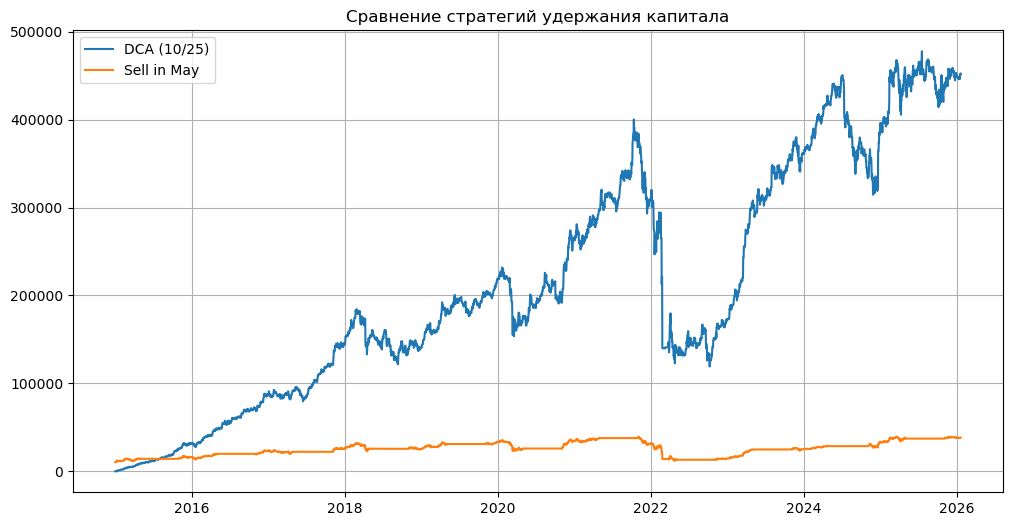

In [ ]:
# Получаем данные (пример)
ret_dca, val_dca, hist_dca = benchmark_dca(df_SBER)
ret_sim, val_sim, hist_sim = benchmark_sell_in_may(df_SBER)
# hist_dep — это history_df из предыдущей функции про вклады

plt.figure(figsize=(12, 6))

plt.plot(hist_dca.index, hist_dca['Balance'], label='DCA (10/25)')
plt.plot(hist_sim.index, hist_sim['Balance'], label='Sell in May')
# Если у вкладов индекс по годам, можно использовать .step() или аппроксимацию
# plt.plot(hist_dep['Year_Date'], hist_dep['Balance'], label='Bank Deposit')

plt.title('Сравнение стратегий удержания капитала')
plt.legend()
plt.grid(True)
plt.show()

Стратегия с банковским вкладом

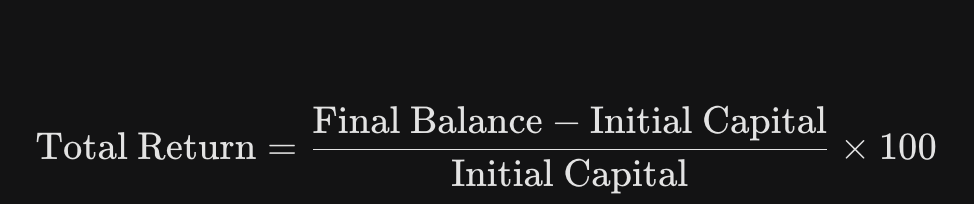

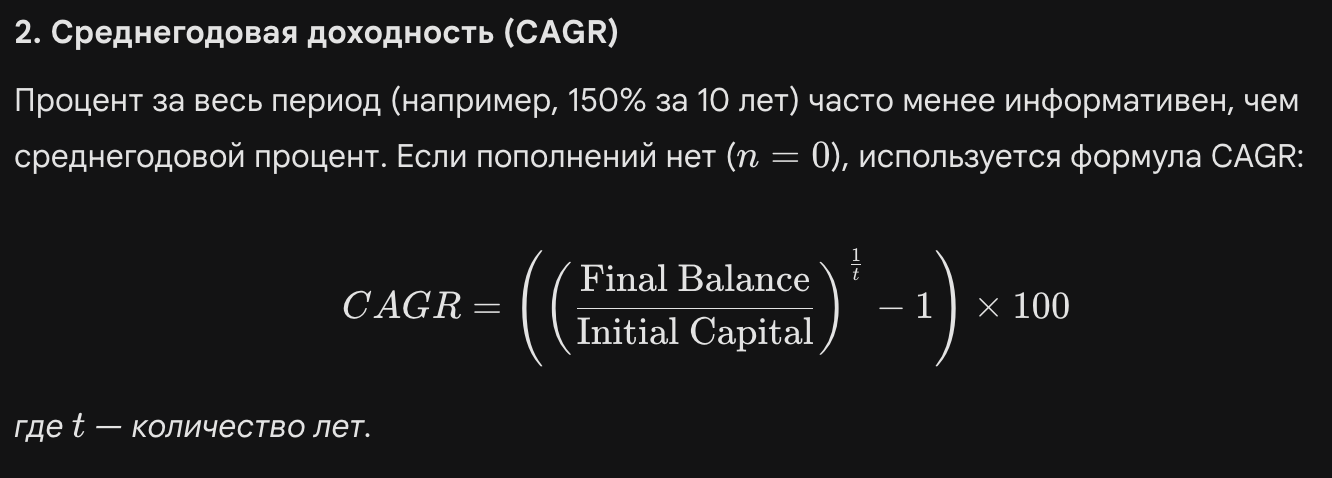

In [ ]:
def benchmark_deposit(df_rates: pd.DataFrame, initial_capital: float = 100000, n: float = 0, start_year: int = 2015, end_year: int = 2025) -> tuple[float, float, pd.DataFrame]:
    """
    initial_capital: Стартовая сумма
    n: Сумма ежегодной капитализации, если она есть
    df_rates: DataFrame с колонкой 'BankRate' и годами в индексе
    start_year: Год начала (int)
    end_year: Год окончания (int)
    
    Returns:
        tuple: (чистая_доходность_%, финальный_баланс, df_history)
    """
    current_balance = initial_capital
    total_invested = initial_capital  # Отслеживаем общую сумму внесенных средств
    history = []
    
    # Добавляем стартовую точку (начало первого года)
    history.append({
        'Year': start_year,
        'Balance': current_balance,
        'Rate': 0,
        'Profit': 0,
        'Invested': initial_capital
    })
    
    # Цикл по годам
    for year in range(start_year, end_year + 1):
        if year in df_rates.index:
            rate = df_rates.loc[year, 'BankRate']
            
            # В конце года получаем выплату
            profit = current_balance * rate
            current_balance += profit
            current_balance += n
            total_invested += n # Учитываем ежегодное пополнение в общей сумме вложений
            
            history.append({
                'Year': year + 1, # Состояние на 1 января следующего года
                'Balance': round(current_balance, 2),
                'Rate': rate,
                'Profit': round(profit, 2), 
                'Invested': round(current_balance, 2) - round(profit, 2)
            })
        else:
            print(f"Предупреждение: Ставка за {year} год не найдена.")
            
    # Превращаем историю в DataFrame для удобного построения графиков
    df_history = pd.DataFrame(history)
    
    # ИЗМЕНЕНИЕ: Считаем доходность только от заработанных процентов (Net ROI), 
    # а не просто разницу между началом и концом, чтобы не учитывать пополнения как прибыль.
    net_profit = current_balance - total_invested
    total_return_pct = (net_profit / total_invested) * 100
    
    return total_return_pct, current_balance, df_history

In [ ]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_deposit(df_market, start_cap, 1000, 2015, 2025)

print(f"Итоговая доходность вкладов: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность вкладов: 174.48%
Финальная сумма: 304677.78
    Year    Balance     Rate    Profit   Invested
0   2015  100000.00  0.00000      0.00  100000.00
1   2016  116325.00  0.15325  15325.00  101000.00
2   2017  128945.87  0.09990  11620.87  117325.00
3   2018  140777.32  0.08400  10831.45  129945.87
4   2019  151976.64  0.07245  10199.32  141777.32
5   2020  164418.96  0.07529  11442.32  152976.64
6   2021  175164.07  0.05927   9745.11  165418.96
7   2022  184021.93  0.04486   7857.86  176164.07
8   2023  199261.55  0.07738  14239.62  185021.93
9   2024  216461.51  0.08130  16199.96  200261.55
10  2025  249482.66  0.14793  32021.15  217461.51
11  2026  304677.78  0.21723  54195.12  250482.66


In [38]:
start_cap = 100000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_sell_in_may(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность sell in may: {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность sell in may: 281.72%
Финальная сумма: 381719.22
    Year    Balance     Rate     Profit  Invested
0   2015  161555.40  0.61555   61555.40    100000
1   2016  232531.25  0.43933   70975.85    100000
2   2017  257201.57  0.10609   24670.32    100000
3   2018  252072.57 -0.01994   -5129.00    100000
4   2019  335389.60  0.33053   83317.03    100000
5   2020  344445.36  0.02700    9055.76    100000
6   2021  310879.82 -0.09745  -33565.54    100000
7   2022  145408.94 -0.53227 -165470.88    100000
8   2023  250489.16  0.72265  105080.22    100000
9   2024  335820.57  0.34066   85331.41    100000
10  2025  381719.22  0.13668   45898.65    100000


In [ ]:
start_cap = 1000 # 100 тысяч рублей
ret_pct, final_val, history_df = benchmark_dca(prepare_daily_data(df_SBER), start_cap, start_year=2015, end_year=2025)

print(f"Итоговая доходность DCA {ret_pct:.2f}%")
print(f"Финальная сумма: {final_val:.2f}")

# Посмотрим на историю роста
print(history_df)

Итоговая доходность DCA 33.89%
Финальная сумма: 251709.18
   Year    Balance     Rate    Profit  Invested
0  2018   18096.32 -1.90368  -1903.68     20000
1  2019   51691.35  0.53022   9595.03     44000
2  2020   84528.56  0.17096   8837.21     68000
3  2021  114376.23  0.06918   5847.67     92000
4  2022   80580.46 -0.50531 -57795.77    116000
5  2023  182362.38  0.96527  77781.92    140000
6  2024  213510.96  0.03920   7148.58    164000
7  2025  251709.18  0.06650  14198.22    188000


In [ ]:
# strategy_results = []

# print(f"Начинаю обработку {len(moex_list)} тикеров...")

# for item in moex_list:
#     ticker = item['ticker']
#     name = item['name']
    
#     print(f"\n>>> {ticker} ({name})")
    
#     try:
#         # Загружаем данные (используем 1day для стратегий на годы)
#         df = get_candles_data(
#             ticker=ticker, 
#             interval_name="1day",
#             start_date=datetime(2021, 1, 1)
#         )
        
#         if df.empty or len(df) < 10: # Проверка на "пустые" или новые листинги
#             print(f"Недостаточно данных для {ticker}")
#             continue

#         # Подготовка данных (предполагаем, что функция prepare_daily_data у вас есть)
#         clean_df = prepare_daily_data(df)

#         # Расчет Стратегии №1: Sell in May
#         ret_may, _, _ = benchmark_sell_in_may(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )
        
#         # Расчет Стратегии №2: DCA
#         ret_dca, _, _ = benchmark_dca(
#             clean_df, start_cap, start_year=2021, end_year=2025
#         )

#         # Сохраняем результат в список
#         strategy_results.append({
#             "Ticker": ticker,
#             "Name": name,
#             "Sell_in_May_Ret_%": round(ret_may, 2),
#             "DCA_Ret_%": round(ret_dca, 2)
#         })
        
#         print(f"Готово. May: {ret_may:.1f}%, DCA: {ret_dca:.1f}%")

#     except Exception as e:
#         print(f"Ошибка при обработке {ticker}: {e}")
#         continue

Начинаю обработку 206 тикеров...

>>> VSMO (ВСМПО-АВИСМА)
[VSMO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VSMO (ВСМПО-АВИСМА), FIGI: BBG004S68CV8
Готово. May: 0.0%, DCA: -12.2%

>>> UNAC (Объединенная авиастроительная корпорация)
[UNAC] Кэш неполный. Докачиваю недостающее...
Подтверждено: UNAC (Объединенная авиастроительная корпорация), FIGI: BBG000Q7ZZY2
Готово. May: 16.5%, DCA: -26.5%

>>> CNRU (Циан)
[CNRU] Кэш неполный. Докачиваю недостающее...
Подтверждено: CNRU (Циан), FIGI: TCS00A10ANA1
Готово. May: 37.9%, DCA: 14.2%

>>> VKCO (ВК)
[VKCO] Кэш неполный. Докачиваю недостающее...
Подтверждено: VKCO (ВК), FIGI: TCS00A106YF0
Готово. May: 15.4%, DCA: -35.1%

>>> MGNT (Магнит)
[MGNT] Кэш неполный. Докачиваю недостающее...
Подтверждено: MGNT (Магнит), FIGI: BBG004RVFCY3
Готово. May: 0.0%, DCA: -37.9%

>>> KZIZ (Красногорский завод им. С.А. Зверева - ао)
[KZIZ] Кэш неполный. Докачиваю недостающее...
Готово. May: 172.2%, DCA: -22.2%

>>> KZOSP (Казаньоргсинтез - акции привилег

In [ ]:
# # 2. Создание DataFrame из списка результатов
# results_df = pd.DataFrame(strategy_results)

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="DCA_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по DCA):
      Ticker                                         Name  Sell_in_May_Ret_%  DCA_Ret_%
47      MRKV                                Россети Волга              45.35     206.28
153     GTRK                                          ГТМ              57.08     189.48
107     PMSB                               Пермэнергосбыт             184.86     149.20
138    PMSBP     Пермэнергосбыт - акции привилегированные             170.56     145.99
60      BSPB                         Банк Санкт-Петербург             116.50     145.91
64      KROT                              Красный Октябрь             458.80     135.03
109     RBCM                                          РБК             368.81     128.72
148     MRKC                                Россети Центр              47.09     119.00
143     MDMG                                  Мать и дитя              70.67     118.90
145     LENT                                        Лента             113.85     117.1

In [ ]:
# # 3. Сортировка по убыванию доходности второй стратегии (DCA)
# if not results_df.empty:
#     results_df = results_df.sort_values(by="Sell_in_May_Ret_%", ascending=False)
#     print("ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):")
#     print(results_df.head(30))
    
#     # Сохранение в CSV/Excel (опционально)
#     # results_df.to_excel("strategy_comparison.xlsx", index=False)
# else:
#     print("Результаты не найдены.")

ИТОГОВАЯ ТАБЛИЦА (TOP 30 по Sell in May):
      Ticker                                       Name  Sell_in_May_Ret_%  DCA_Ret_%
133     NTZL                                      НИТЕЛ            1027.98     -36.16
64      KROT                            Красный Октябрь             458.80     135.03
109     RBCM                                        РБК             368.81     128.72
132  VEON-RX                                       VEON             297.80      62.75
156     FESH                                       ДВМП             256.65      53.09
6      KZOSP  Казаньоргсинтез - акции привилегированные             237.39     -23.91
20      GRNT         Городские Инновационные Технологии             236.13     -18.65
107     PMSB                             Пермэнергосбыт             184.86     149.20
113     BLNG                                      Белон             176.58      -8.50
39     TGKBP            ТГК-2 - акции привилегированные             175.43       6.26
5       KZIZ

Бенчмарк инфляции: 51.25%
Бенчмарк вклада: 70.08%


,Ticker,Name,Sell_in_May_Ret_%,DCA_Ret_%,Beats_Inflation,Beats_Bank,Real_Ret_%,Beats_Inflation_DCA,Beats_Bank_DCA,Beats_Inflation_SIM,Beats_Bank_SIM,Real_Ret_DCA%,Real_Ret_SIM%
133,NTZL,НИТЕЛ,1027.98,-36.16,False,False,-87.411864,False,False,True,True,-87.411864,976.728136
64,KROT,Красный Октябрь,458.80,135.03,True,True,83.778136,True,True,True,True,83.778136,407.548136
109,RBCM,РБК,368.81,128.72,True,True,77.468136,True,True,True,True,77.468136,317.558136
132,VEON-RX,VEON,297.80,62.75,True,False,11.498136,True,False,True,True,11.498136,246.548136
156,FESH,ДВМП,256.65,53.09,True,False,1.838136,True,False,True,True,1.838136,205.398136



СРЕДНЯЯ ДОХОДНОСТЬ (DCA): 6.24%
МЕДИАННАЯ ДОХОДНОСТЬ (DCA): -4.04%
ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): 27 из 206
СРЕДНЯЯ ДОХОДНОСТЬ (SIM): 39.37%
МЕДИАННАЯ ДОХОДНОСТЬ (SIM): 16.50%
ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): 53 из 206


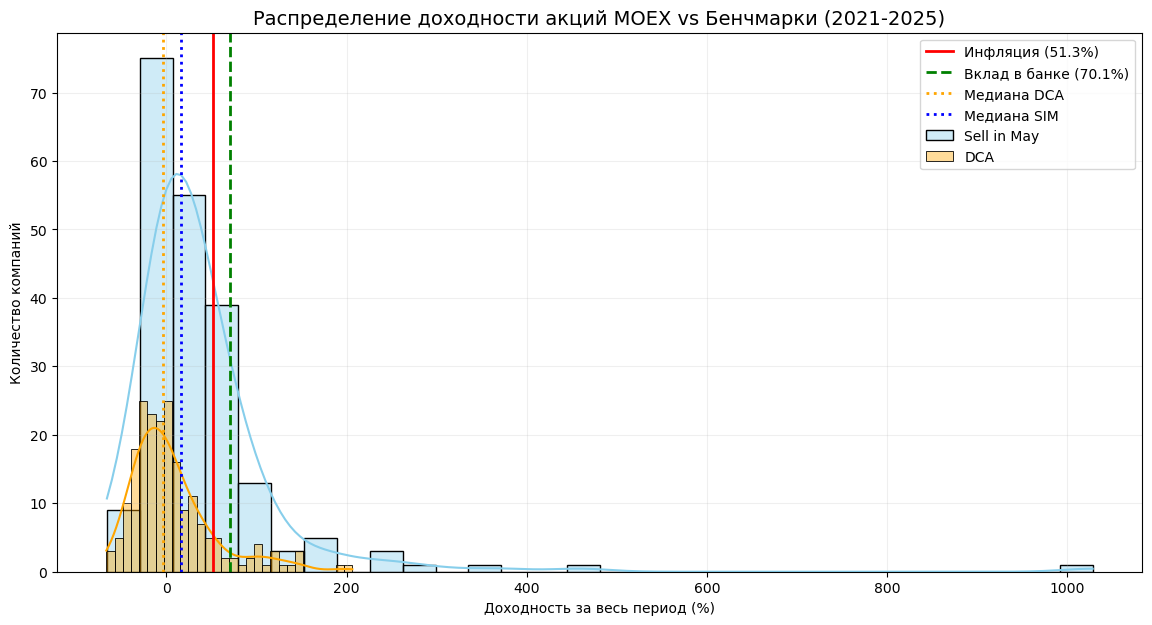

In [ ]:
# # 1. Убеждаемся, что переменные бенчмарков рассчитаны
# df_period = df_market[df_market.index >= 2021]
# total_inflation_pct = ((df_period['Inflation'] + 1).prod() - 1) * 100
# total_bank_pct = ((df_period['BankRate'] + 1).prod() - 1) * 100

# # 2. Добавляем новые колонки в готовый results_df
# results_df['Beats_Inflation_DCA'] = results_df['DCA_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_DCA'] = results_df['DCA_Ret_%'] > total_bank_pct
# results_df['Beats_Inflation_SIM'] = results_df['Sell_in_May_Ret_%'] > total_inflation_pct
# results_df['Beats_Bank_SIM'] = results_df['Sell_in_May_Ret_%'] > total_bank_pct

# # 3. Можно также добавить колонку с "Чистой доходностью" (доходность минус инфляция)
# results_df['Real_Ret_DCA%'] = results_df['DCA_Ret_%'] - total_inflation_pct
# results_df['Real_Ret_SIM%'] = results_df['Sell_in_May_Ret_%'] - total_inflation_pct

# # Проверяем результат
# print(f"Бенчмарк инфляции: {total_inflation_pct:.2f}%")
# print(f"Бенчмарк вклада: {total_bank_pct:.2f}%")
# display(results_df.head())

# print("\n" + "="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (DCA): {results_df['DCA_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (DCA): {results_df['Beats_Inflation_DCA'].sum()} из {len(results_df)}")
# print("="*50)
# print(f"СРЕДНЯЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].mean():.2f}%")
# print(f"МЕДИАННАЯ ДОХОДНОСТЬ (SIM): {results_df['Sell_in_May_Ret_%'].median():.2f}%")
# print(f"ОБОГНАЛИ ИНФЛЯЦИЮ (SIM): {results_df['Beats_Inflation_SIM'].sum()} из {len(results_df)}")
# print("="*50)

# # Построение графиков
# plt.figure(figsize=(14, 7))
# sns.histplot(results_df["Sell_in_May_Ret_%"], color="skyblue", label="Sell in May", kde=True, bins=30, alpha=0.4)
# sns.histplot(results_df["DCA_Ret_%"], color="orange", label="DCA", kde=True, bins=30, alpha=0.4)

# # Линии бенчмарков
# plt.axvline(total_inflation_pct, color='red', linestyle='-', linewidth=2, label=f'Инфляция ({total_inflation_pct:.1f}%)')
# plt.axvline(total_bank_pct, color='green', linestyle='--', linewidth=2, label=f'Вклад в банке ({total_bank_pct:.1f}%)')
# plt.axvline(results_df["DCA_Ret_%"].median(), color='orange', linestyle=':', linewidth=2, label='Медиана DCA')
# plt.axvline(results_df["Sell_in_May_Ret_%"].median(), color='blue', linestyle=':', linewidth=2, label='Медиана SIM')

# plt.title("Распределение доходности акций MOEX vs Бенчмарки (2021-2025)", fontsize=14)
# plt.xlabel("Доходность за весь период (%)")
# plt.ylabel("Количество компаний")
# plt.legend()
# plt.grid(alpha=0.2)
# plt.show()